## Importing Packages and Configuring

In [1]:
import pandas as pd
import numpy as np

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better display in Jupyter
%matplotlib inline

# Set default figure size for all plots (width, height in inches)
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 5)  # Larger default size
matplotlib.rcParams['figure.dpi'] = 100          # Resolution
matplotlib.rcParams['font.size'] = 11            # Default font size

# Configure Seaborn style
sns.set_style("whitegrid")                       # Clean grid background
sns.set_palette("deep")                          # Colorblind-friendly palette
sns.set_context("notebook")                      # Appropriate scaling

#for geospacial plotting
import warnings
# Suppress all non-critical warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets

## Data quality check / cleaning / preparation 

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.** An example is given below.

### Exploring Initial Data
*By Grace Gormley*

In [2]:
#Making my divvy dataset from 2024-2025
import glob #gonna be honest, I got this from chat so I dont need to do it one by one

files = glob.glob("/Users/gracegormley/Desktop/Stat 303-1/project/divvy 2024-2025/*.csv")   # grabs all CSVs in the folder

dfs = []                                      # empty list to store DataFrames
for f in files:
    dfs.append(pd.read_csv(f))

divvy = pd.concat(dfs, ignore_index=True)

In [3]:
#make sure they're in chronological order
divvy["started_at"] = pd.to_datetime(divvy["started_at"], format="mixed")
divvy = divvy.sort_values(by="started_at")

In [4]:
#Importing my extra datasets
traffic = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Chicago_Traffic_Tracker_-_Congestion_Estimates_by_Segments_20251125.csv')
CTA_riders = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_-_Ridership_-_Daily_Boarding_Totals_20251125.csv')
bus_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_BusStops_20251125.csv')
L_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_-_System_Information_-_List_of_\'L\'_Stops_20251125.csv')
population = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Chicago_Population_Counts_20251125.csv')

In [5]:
#Printing the head of each dataset to get an idea of the contents

In [6]:
divvy.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member


In [41]:
traffic.tail(60)

,SEGMENTID,STREET,DIRECTION,FROM_STREET,TO_STREET,LENGTH,STREET_HEADING,COMMENTS,START_LONGITUDE,START_LATITUDE,...,END_LATITUDE,CURRENT_SPEED,LAST_UPDATED,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
1197,1203,Halsted,NB,83rd,79th,0.500000,S,NaN,-87.643641,41.743359,...,41.750643,25,2025-11-25 07:40:22.0,POINT (-87.64364 41.74336),70.0,71.0,AUBURN GRESHAM,71,1.050654e+08,46757.721716
1198,204,North,WB,Central Park,Pulaski,0.490000,W,NaN,-87.716699,41.910131,...,41.910024,16,2025-11-25 07:40:04.0,POINT (-87.7167 41.91013),22.0,23.0,HUMBOLDT PARK,23,1.004809e+08,48583.064330
1199,782,Peterson,EB,Damen,Ridge,0.390000,W,NaN,-87.679861,41.990550,...,41.990643,22,2025-11-25 07:40:24.0,POINT (-87.67986 41.99055),3.0,4.0,LINCOLN SQUARE,4,7.135233e+07,36624.603085
1200,332,Western,NB,91st,87th,0.500000,S,IDOT Signals Possible,-87.682116,41.728229,...,41.735526,29,2025-11-25 07:40:09.0,POINT (-87.68212 41.72823),71.0,72.0,BEVERLY,72,8.877936e+07,44591.485101
1201,895,Lake Shore Dr,SE,Lawrence,Montrose,0.520000,N,NaN,-87.648153,41.969406,...,41.962008,47,2025-11-25 07:40:21.0,POINT (-87.64815 41.96941),2.0,3.0,UPTOWN,3,6.509564e+07,46972.794555
1202,55,Pulaski,NB,Lawrence,Foster,0.500000,N,NaN,-87.727844,41.968241,...,41.975531,18,2025-11-25 07:40:06.0,POINT (-87.72784 41.96824),13.0,14.0,ALBANY PARK,14,5.354223e+07,39339.016439
1203,565,Cicero,NB,67th,63rd,0.500000,S,NaN,-87.741866,41.771125,...,41.778410,25,2025-11-25 07:40:14.0,POINT (-87.74187 41.77113),64.0,65.0,WEST LAWN,65,8.231530e+07,41934.490131
1204,931,Milwaukee,NW,Peterson,Devon,0.610000,N,NaN,-87.780851,41.990195,...,41.997351,-1,2025-11-25 07:40:26.0,POINT (-87.78085 41.99019),9.0,10.0,NORWOOD PARK,10,1.219591e+08,80368.374378
1205,76,Pulaski,SB,31st,I-55 Expy,0.950000,S,NaN,-87.724601,41.836885,...,41.822994,20,2025-11-25 07:40:07.0,POINT (-87.7246 41.83689),29.0,30.0,SOUTH LAWNDALE,30,1.279983e+08,49904.045210
1206,634,Cicero,SB,63rd,67th,0.500000,S,NaN,-87.742481,41.778412,...,41.771127,-1,2025-11-25 07:40:17.0,POINT (-87.74248 41.77841),63.0,64.0,CLEARING,64,7.114519e+07,45363.286175


In [8]:
CTA_riders.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,01/01/2001,U,"297,192","126,455","423,647"
1,01/02/2001,W,"780,827","501,952","1,282,779"
2,01/03/2001,W,"824,923","536,432","1,361,355"
3,01/04/2001,W,"870,021","550,011","1,420,032"
4,01/05/2001,W,"890,426","557,917","1,448,343"


In [9]:
bus_stops.tail(70)

,the_geom,SYSTEMSTOP,STREET,CROSS_ST,DIR,POS,ROUTESSTPG,OWLROUTES,CITY,PUBLIC_NAM
10690,POINT (-87.74481606799998 41.862335599000005),"10,258",CICERO,14TH STREET,SB,NS,54,NaN,CICERO,Cicero & 14th Street
10691,POINT (-87.628356 41.89926400000002),"5,375",STATE,DELAWARE,SB,NS,36,NaN,CHICAGO,State & Delaware
10692,POINT (-87.654837999 41.96342100099997),"1,050",SHERIDAN,SUNNYSIDE,SB,FS,151,NaN,CHICAGO,Sheridan & Sunnyside
10693,POINT (-87.68103544299998 41.828731903000005),"4,432",35TH/ARCHER,ORANGE LINE STATION,SWB,TERM,35,NaN,CHICAGO,35th/Archer Orange Line Station
10694,POINT (-87.5400057 41.65944309499997),"7,297",AVENUE O,130TH STREET,SB,NS,30,NaN,CHICAGO,Avenue O & 130th Street
...,...,...,...,...,...,...,...,...,...,...
10755,POINT (-87.69960900000001 42.02665914200003),"14,738",DODGE,OAKTON,SB,NS,93,NaN,EVANSTON,Dodge & Oakton
10756,POINT (-87.714284169 41.933375263000016),"5,563",MILWAUKEE,WISNER,NWB,NS,56,NaN,CHICAGO,Milwaukee & Wisner
10757,POINT (-87.81891211099997 42.00458322200001),"9,910",NORTHWEST HWY,OVERHILL,NWB,FS,68,NaN,CHICAGO,Northwest Hwy & Overhill
10758,POINT (-87.67733964000001 42.053723761000015),"17,295",SHERIDAN,FOSTER,SB,FS,201,NaN,EVANSTON,Sheridan & Foster


In [10]:
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,False,False,False,False,False,"(41.831677, -87.625826)"


In [11]:
population.head()

,Geography Type,Year,Geography,Population - Total,Population - Age 0-17,Population - Age 18-29,Population - Age 30-39,Population - Age 40-49,Population - Age 50-59,Population - Age 60-69,...,Population - Age 18+,Population - Age 65+,Population - Female,Population - Male,Population - Latinx,Population - Asian Non-Latinx,Population - Black Non-Latinx,Population - White Non-Latinx,Population - Other Race Non-Latinx,Record ID
0,Citywide,2018,Chicago,"2,705,988","548,999","552,935","456,321","336,457","312,965","262,991",...,"2,156,989","349,712","1,386,113","1,319,875","776,661","179,841","784,266","899,980","119,467",Citywide-Chicago-2018
1,ZIP Code,2018,60601,"14,675",820,"4,606","2,792","2,190","1,333","1,340",...,"13,855","2,075","7,484","7,191","1,274",NaN,NaN,"9,677",NaN,ZIP_Code-60601-2018
2,ZIP Code,2018,60602,"1,244",149,435,462,135,53,10,...,"1,095",5,551,693,81,NaN,NaN,788,NaN,ZIP_Code-60602-2018
3,ZIP Code,2018,60603,"1,174",56,561,101,97,197,97,...,"1,118",112,601,573,115,NaN,NaN,707,NaN,ZIP_Code-60603-2018
4,ZIP Code,2018,60604,782,38,303,104,51,101,130,...,744,93,413,369,34,NaN,NaN,479,NaN,ZIP_Code-60604-2018


#### Finding missing values

In [12]:
divvy.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    2155418
start_station_id      2155418
end_station_name      2236017
end_station_id        2236017
start_lat                   0
start_lng                   0
end_lat                 12288
end_lng                 12288
member_casual               0
dtype: int64

In [13]:
traffic.isnull().sum()

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
dtype: int64

In [14]:
CTA_riders.isnull().sum()

service_date      0
day_type          0
bus               0
rail_boardings    0
total_rides       0
dtype: int64

In [15]:
bus_stops.isnull().sum()

the_geom         0
SYSTEMSTOP       0
STREET           0
CROSS_ST         0
DIR              0
POS              0
ROUTESSTPG       4
OWLROUTES     8602
CITY             1
PUBLIC_NAM       0
dtype: int64

In [16]:
L_stops.isnull().sum()

STOP_ID                     0
DIRECTION_ID                0
STOP_NAME                   0
STATION_NAME                0
STATION_DESCRIPTIVE_NAME    0
MAP_ID                      0
ADA                         0
RED                         0
BLUE                        0
G                           0
BRN                         0
P                           0
Y                           0
Pnk                         0
O                           0
Location                    0
dtype: int64

In [17]:
population.isnull().sum()

Geography Type                         0
Year                                   0
Geography                              0
Population - Total                     0
Population - Age 0-17                  0
Population - Age 18-29                 0
Population - Age 30-39                 0
Population - Age 40-49                 0
Population - Age 50-59                 0
Population - Age 60-69                 0
Population - Age 70-79                 0
Population - Age 80+                   0
Population - Age 0-4                   0
Population - Age 5-11                 59
Population - Age 12-17                59
Population - Age 5+                    0
Population - Age 18+                   0
Population - Age 65+                   0
Population - Female                    0
Population - Male                      0
Population - Latinx                    0
Population - Asian Non-Latinx         59
Population - Black Non-Latinx         59
Population - White Non-Latinx          0
Population - Oth

#### Visualizing the neigborhoods (from textbook)

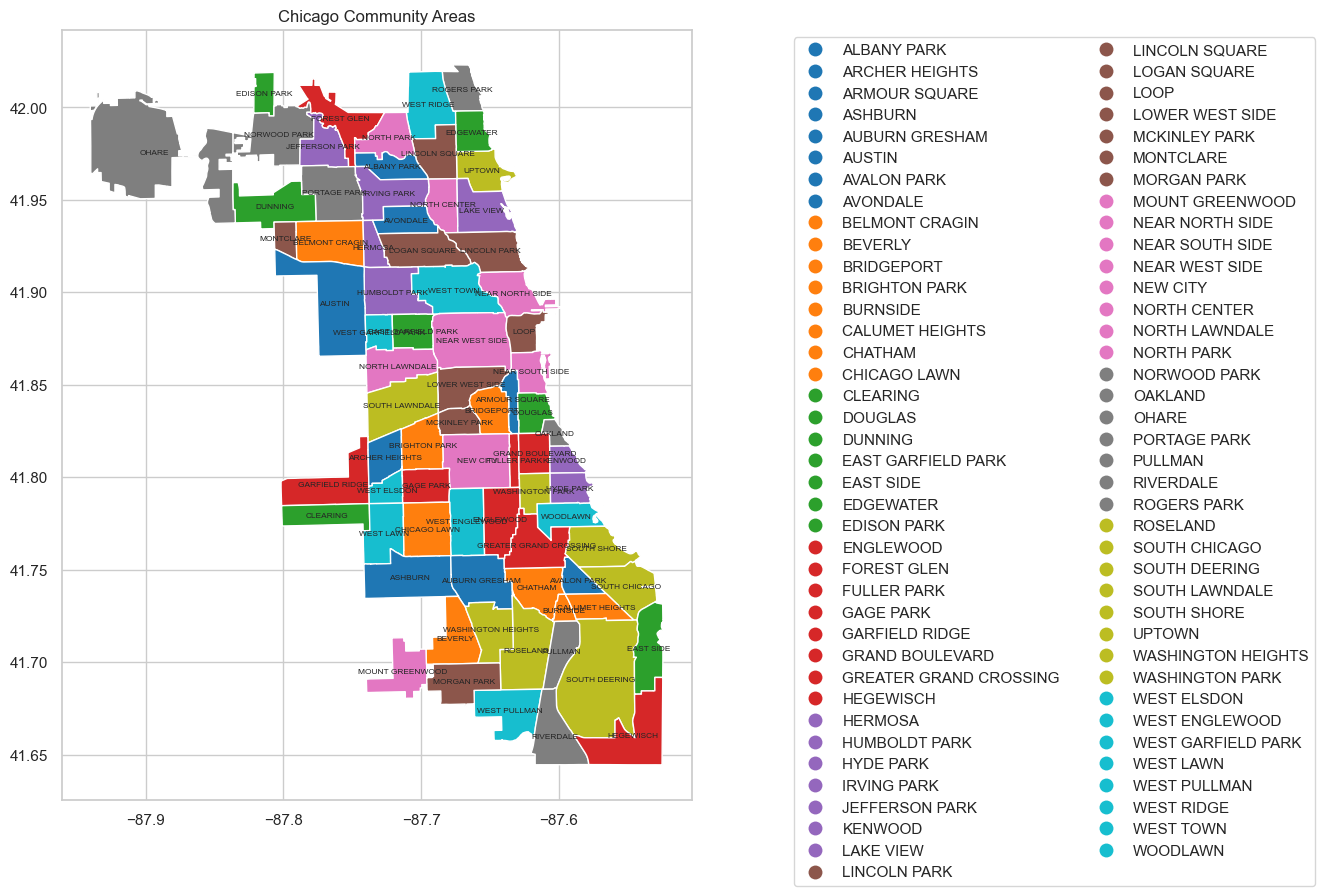

In [18]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# Plot your GeoDataFrame
chicago = gpd.read_file(r'/Users/gracegormley/Desktop/Stat 303-1/project/Boundaries - Community Areas_20251127/geo_export_a0f75e4e-d093-4b60-9319-7b3e6e34a0ad.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})
# Add community labels
for idx, row in chicago.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(
        x, y,
        row['community'],
        fontsize=6,
        ha='center',
        va='center'
    )

# Add title (optional)
plt.title('Chicago Community Areas');

#### Assigning neighborhoods in the dataframes

In [19]:
#Okay, for this part, I had chat explain the workflow to me

    #Step 1 (since we already have shapefile as geospacial object): convert dataframe
from shapely.geometry import Point
gdf_points = gpd.GeoDataFrame(divvy, geometry = gpd.points_from_xy(divvy.start_lng, divvy.start_lat), crs = "EPSG:4326")

In [20]:
    #Step 2: Making sure they have same coordinate system
print(chicago.crs)
print(gdf_points.crs)

    #Step 3: Now I assign each row to its neighborhood
divvy_nb = gpd.sjoin(gdf_points, chicago, how="left", predicate="within")

EPSG:4326
EPSG:4326


In [21]:
divvy_nb.head()
#YAYYYY

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member,POINT (-87.65 41.95),5.0,6.0,LAKE VIEW,6,8.721480e+07,51973.096868
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member,POINT (-87.6413 41.88191),27.0,28.0,NEAR WEST SIDE,28,1.584925e+08,53003.592941
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member,POINT (-87.6317 41.89076),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952


In [22]:
#I'll do that with Traffic -  its the only clean one
gdf_points1 = gpd.GeoDataFrame(traffic, geometry = gpd.points_from_xy(traffic['START_LONGITUDE'], traffic[' START_LATITUDE']), crs = "EPSG:4326") #dumb space before lat :\
traffic = gpd.sjoin(gdf_points1, chicago, how="left", predicate="within")

In [23]:
traffic.head()
traffic.isnull().sum() #some missing community values... maybe I should try to find where that is (later tho)

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
geometry              0
index_right         159
area_numbe          159
community           159
area_num_1          159
shape_area          159
shape_len           159
dtype: int64

In [24]:
#splitting bus stops and L stops into two coords
    #bus stops
bus_stops["coords_clean"] = (
    bus_stops["the_geom"]
    .str.replace("POINT (", "", regex=False)
    .str.replace(")", "", regex=False)
)
bus_stops[["LON", "LAT"]] = bus_stops["coords_clean"].str.split(" ", expand=True)
bus_stops["LON"] = bus_stops["LON"].astype(float)
bus_stops["LAT"] = bus_stops["LAT"].astype(float)

gdf_points2 = gpd.GeoDataFrame(bus_stops, geometry = gpd.points_from_xy(bus_stops['LON'], bus_stops['LAT']), crs = "EPSG:4326")
bus_stops = gpd.sjoin(gdf_points2, chicago, how="left", predicate="within")


In [25]:
    #L stops
L_stops["coords_clean"] = (
    L_stops["Location"]
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
L_stops[["LAT", "LON"]] = L_stops["coords_clean"].str.split(",", expand=True)
L_stops["LON"] = L_stops["LON"].astype(float)
L_stops["LAT"] = L_stops["LAT"].astype(float)

gdf_points3 = gpd.GeoDataFrame(L_stops, geometry = gpd.points_from_xy(L_stops['LON'], L_stops['LAT']), crs = "EPSG:4326")
L_stops = gpd.sjoin(gdf_points3, chicago, how="left", predicate="within")
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,...,coords_clean,LAT,LON,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,...,"41.831677, -87.625826",41.831677,-87.625826,POINT (-87.62583 41.83168),34.0,35.0,DOUGLAS,35,4.600462e+07,31027.054510


#### Visualizing the placement of variables

Text(0.5, 1.0, 'Chicago Community Areas with Points')

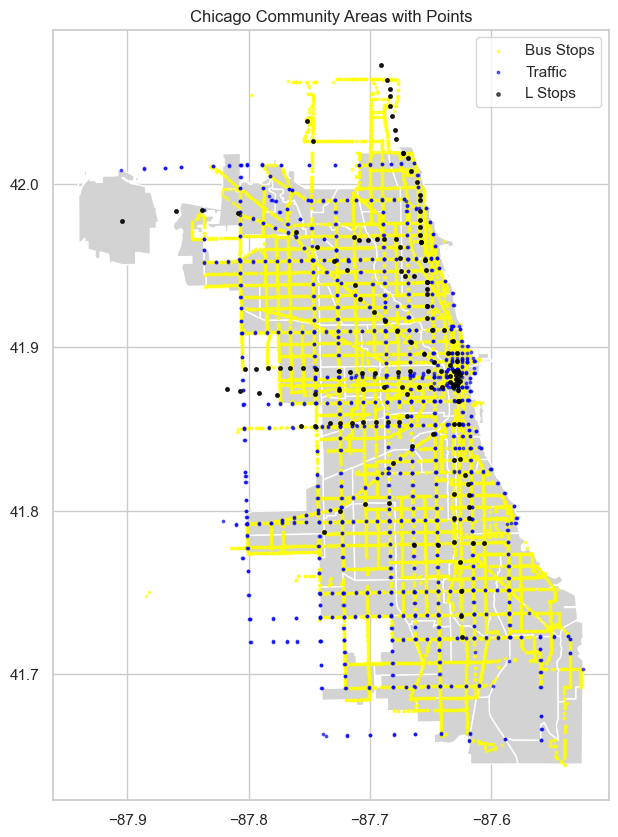

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(column='community', ax=ax, color='lightgray',    # light neutral background
    edgecolor='white', legend=False,
             legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

gdf_points2.plot(ax=ax, color='yellow', markersize=3, alpha=0.6, label='Bus Stops')
gdf_points1.plot(ax=ax, color='blue', markersize=3, alpha=0.6, label='Traffic')
gdf_points3.plot(ax=ax, color='black', markersize=6, alpha=0.6, label='L Stops')

#gdf_points.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='divvy_ride_start') this shows the divvy points and is 

plt.legend()
plt.title('Chicago Community Areas with Points')


I did that ^ to see if there are obviously messed up values (when I loaded the divvy data there was a lot that was uhhh in the lake... so I'll have to deal with that). Other than that it looks pretty clean. 

#### Understanding more complex dataframes
- I don't really understand traffic nor the population. Let's try to clear those up...

In [ ]:
#for traffic: A value of -1 means no estimate is available, so I'll clean them up and get rid of them
traffic_cleaned = traffic[traffic[' CURRENT_SPEED'] != -1]

traffic_cleaned.tail(60)

traffic_cleaned_neighb = traffic_cleaned.groupby(['community'])[' CURRENT_SPEED'].agg(['mean'])
traffic_cleaned_neighb





,mean
community,
ALBANY PARK,22.333333
ARCHER HEIGHTS,23.555556
ARMOUR SQUARE,23.750000
ASHBURN,25.304348
AUBURN GRESHAM,23.107143
...,...
WEST LAWN,24.888889
WEST PULLMAN,32.333333
WEST RIDGE,22.285714


In [27]:
#...Plot for distribution of variables...#

### Data cleaning
*By Sankaranarayanan Balasubramanian & Fiona Fe*

In [28]:
#...Code with comments...#

# Imputing missing values #

### Data preparation
*By Ryu Kimiko*


In [29]:
######---------------Creating new variables----------------#########

#Creating number of bedrooms per unit floor area

#Creating ratio of bathrooms to bedrooms

#Creating ratio of carpet area to floor area

In [30]:
######-----Standardizing the dataset ----------------------#########

## Exploratory data analysis

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

### Analysis 1
*By \<Name of person doing the analysis>*

### Analysis 2
*By \<Name of person doing the analysis>*

### Analysis 3
*By \<Name of person doing the analysis>*

### Analysis 4
*By \<Name of person doing the analysis>*

## Other sections

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

Put each model in a section of its name and mention the name of the team-member tuning the model. Below is an example:

## Conclusions and Recommendations to stakeholder(s)

You may or may not have code to put in this section. Delete this section if it is irrelevant.